# 1. Data Loading and Cleaning

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Melbourne = pd.read_csv("data/MelbourneJune.csv").copy()
Sydney = pd.read_csv("data/SydneyJune.csv").copy()
Brisbane = pd.read_csv("data/BrisbaneJune.csv").copy()
Tasmania = pd.read_csv("data/TasmaniaJune.csv").copy()
WesternAustralia = pd.read_csv("data/WesternAustraliaJune.csv").copy()

In [ ]:
major_cities = [Melbourne, Sydney, Brisbane, Tasmania, WesternAustralia]
drop_cols = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 
             'host_name', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'host_picture_url', 
             'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_has_profile_pic', 'neighbourhood', 'neighbourhood_group_cleansed',
            'property_type', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
            'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_last_scraped', 'number_of_reviews_ltm', 'host_identity_verified', 
            'number_of_reviews_l30d', 'has_availability', 'availability_eoy', 'first_review', 'calculated_host_listings_count_entire_homes',
            'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'host_acceptance_rate',
            'reviews_per_month', 'estimated_revenue_l365d', 'license', 'review_scores_accuracy', 'review_scores_cleanliness',
            'review_scores_checkin', 'review_scores_communication', 'review_scores_value', 'last_review', 'bathrooms_text']

for city in major_cities:
    city.dropna(axis = 1, how = 'all', inplace = True) #  Drop columns where EVERY ("ALL") values are missing and edit the dataset 
    city.drop(columns = drop_cols, inplace = True, errors = 'ignore') # Drop columns that are not useful for our analysis
    city['price'] = city['price'].str.replace('$', '').str.replace(',', '').astype(float) # Convert price from string to float for numerical analysis and visualisation
    city.dropna(subset = ['price'], inplace = True) # Drop rows for listings where price does not exists
    city['estimated_revenue'] = city['price'] * city['estimated_occupancy_l365d'] # Estimate revenue for each listing for later comparisons and visualisations
    # This is just an estimated calculation of revenue used by estimated_occupancy across a year (originally from Airbnb's raw data)
    missing_counts = city.isna().sum()

    if 'bedrooms' in city.columns and missing_counts.get('bedrooms', 0) > 100: # There are a lot of missing values in the "bedrooms" column, so we will infer the value from the "accommodates" column divided by 2 (assuming an average of 2 guests per bedroom)
        city['bedrooms'] = city['bedrooms'].fillna(city['accommodates'] // 2) # Impute missing values in the "bedrooms" column by filling them with the value from the "accommodates" column divided by 2 (assuming an average of 2 guests per bedroom)

    if 'beds' in city.columns and missing_counts.get('beds', 0) > 100: 
        city['beds'] = city['beds'].fillna(city['accommodates'] // 2)

    if 'bathrooms' in city.columns and missing_counts.get('bathrooms', 0) > 100: #  Calculate the normal number of bathrooms for each bedroom count and fill the holes with that number.      
        city['bathrooms'] = city['bathrooms'].fillna(city.groupby('bedrooms')['bathrooms'].transform('median'))

After removing duplicate and insignificant columns from our city datasets, we observed remaining missing values in key areas such as review_scores for location and ratings, host dates, bedrooms and bathrooms counts. It was not sensible to correct these missing data by filling in the values with 0, as it is both factually introduce and can introduce significant bias into our analysis. Therefore, we have chosen to retain these as Na/NaN values and will utilise functions that automatically exclude them during aggregation or analysis to maintain accuracy. The missing bedrooms and bathrooms values have been dealt with by calculating similar listings with same number of bedrooms and bathrooms and using the median or inferring from the accommodates column to ensure that our estimations remain realistic. Additionally, listings without a price have been removed from our analysis.

# Exploratory Data Analysis

### Price Distribution 

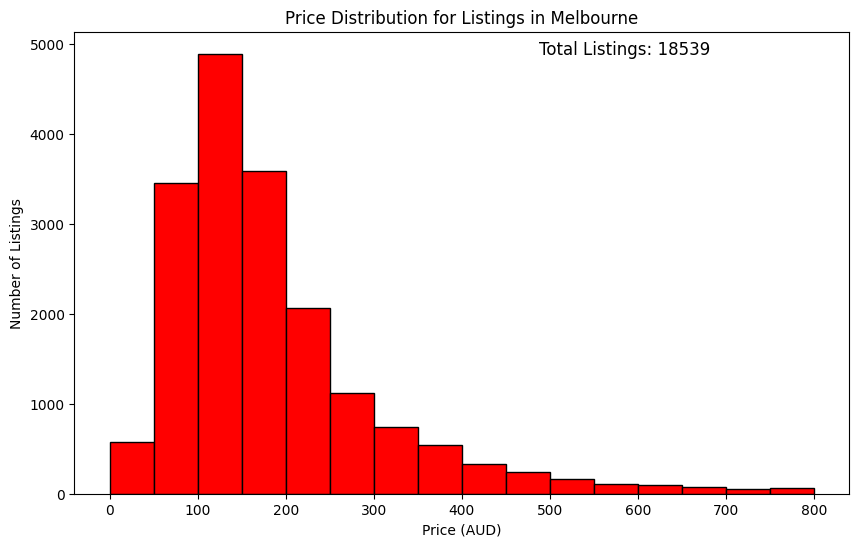

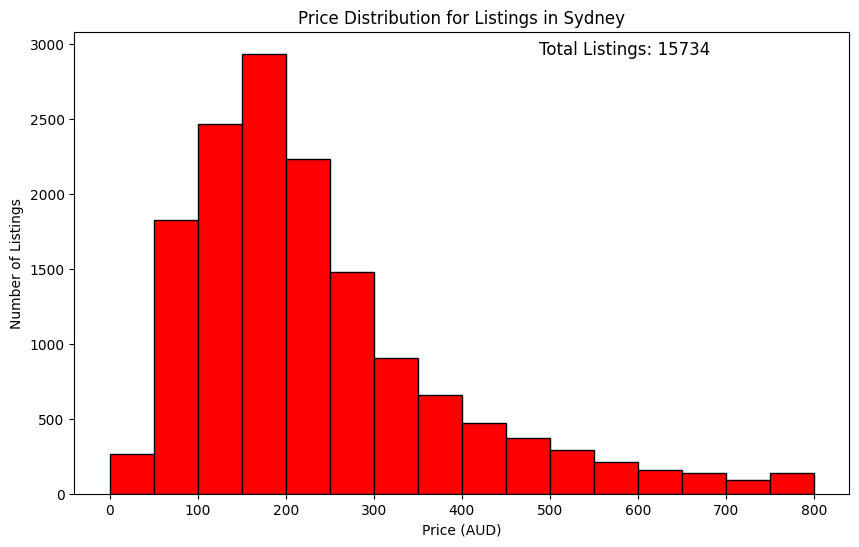

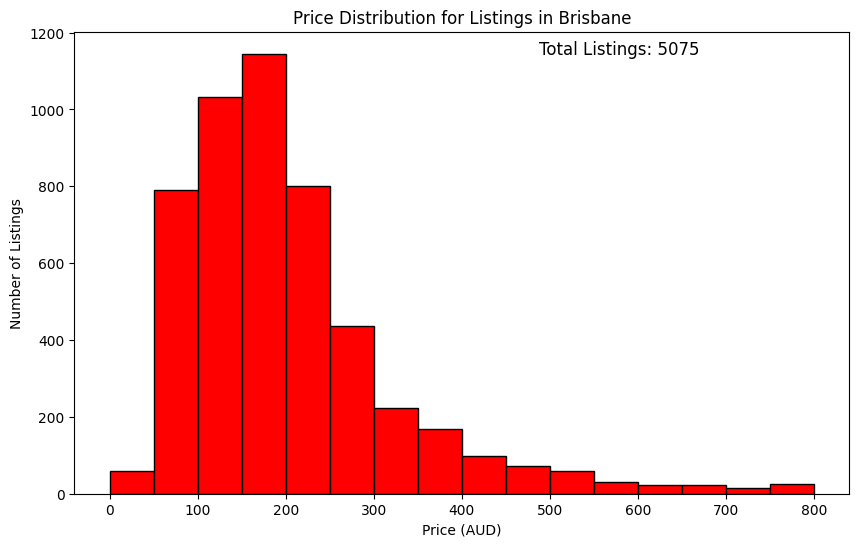

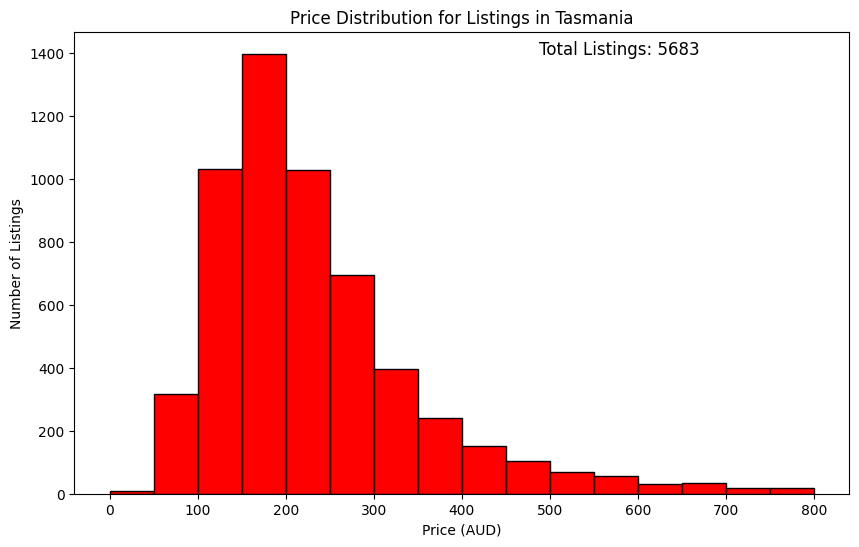

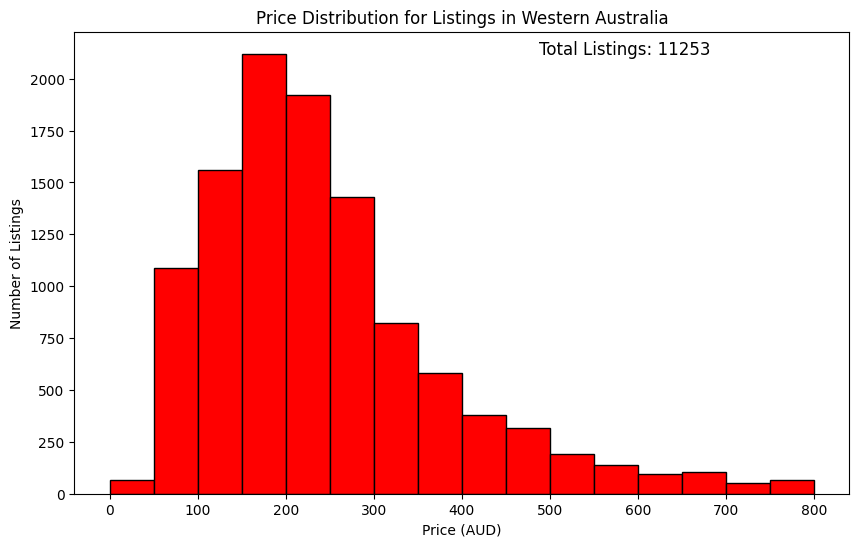

In [81]:
major_cities = {"Melbourne": Melbourne, "Sydney": Sydney, "Brisbane": Brisbane, "Tasmania": Tasmania, "Western Australia": WesternAustralia}

for city_name, city in major_cities.items():
    plt.figure(figsize=(10, 6))
    plt.hist(city['price'], range=(0, 800), bins=16, color= 'red', edgecolor= 'black') # Plot a histogram of the price distribution for each city, with a range of 0 to 800 AUD and 16 bins (50 AUD intervals)
    plt.title('Price Distribution for Listings in ' + city_name)
    plt.xlabel('Price (AUD)')
    plt.ylabel('Number of Listings')
    plt.text(0.6, 0.95, 'Total Listings: ' + str(len(city)), fontsize=12, transform=plt.gca().transAxes)
    plt.show()




The price distribution across all five cities show a clear and consistent right-skewed pattern, with the majority of listings priced between $50 and $300 per night. Notably, Sydney, Brisbane, Western Australia and Tasmania all share a mode bracket of $150 to $200, while Melbourne sits lower at $100 to $150. Melbourne's lower mode is particular interesting given that it has the highest listing volume of all regions, having around 17% more than Sydney. This combination of a higher supply and lower mode in listing price could be from several reasons, for example greater competitiveness, weaker tourism or a stronger local preference for hotel accommodation. As expected, there are outlier prices in each city, with listing prices above $600 per night, which appear more frequently in Sydney and, more surprisingly, Western Australia.

In [82]:
for name, df in major_cities.items(): # Add the city name to dataset
    df['city'] = name

combined = pd.concat(major_cities.values(), ignore_index=True) # Combine all the cities into one dataset for easier analysis and visualisation



### Listings Specifications

Let us just have a peek at the various listings that Airbnb has across cities in Australia

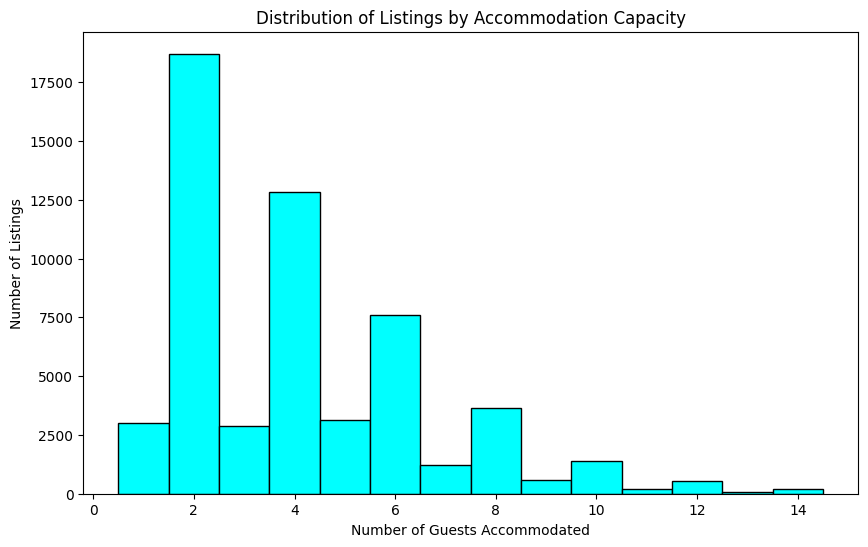

In [83]:
plt.figure(figsize=(10, 6))
plt.hist(combined['accommodates'], bins=range(1, combined['accommodates'].max()), edgecolor = 'black', align = 'left', color = 'aqua')
plt.xlabel('Number of Guests Accommodated')
plt.ylabel('Number of Listings')
plt.title('Distribution of Listings by Accommodation Capacity')
plt.show()

Although appearing basic and simple, there are some insights to be learned from the distribution of listings by accommodation capacity. We see that the most common listings are for 2 guests, 4 guests, 6 guests etc, for even number of guests which decrease at an exponential rate. We could probably extrapolate this from the idea of bedrooms naturally sleep guests in pairs. However, this raises an interesting question for Airbnb hosts: Should we strategically list our capacity around even numbers? Will a property that can accommodate 4 guests (as opposed to 5) have a better booking rate? Or is the number not meaningful? We will look at this later on.

### Host Information

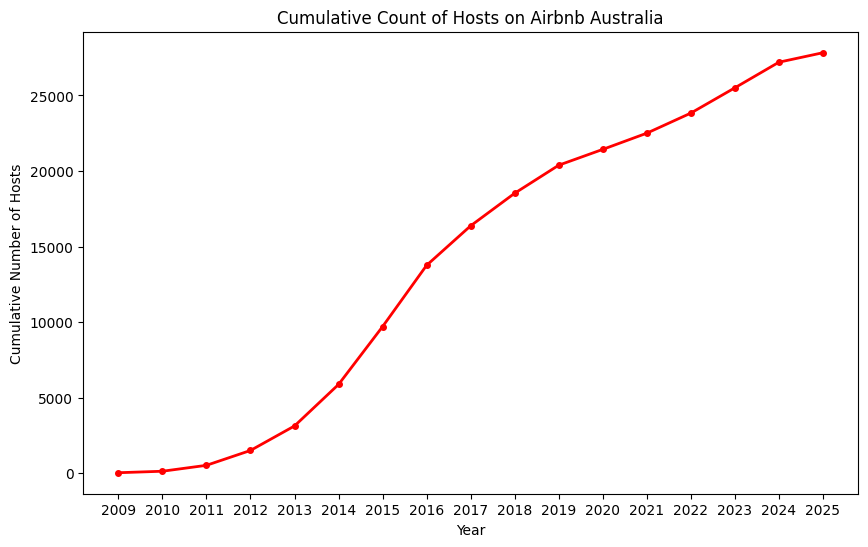

Text(0.5, 1.0, 'Distribution of Airbnb Hosts across Australia')

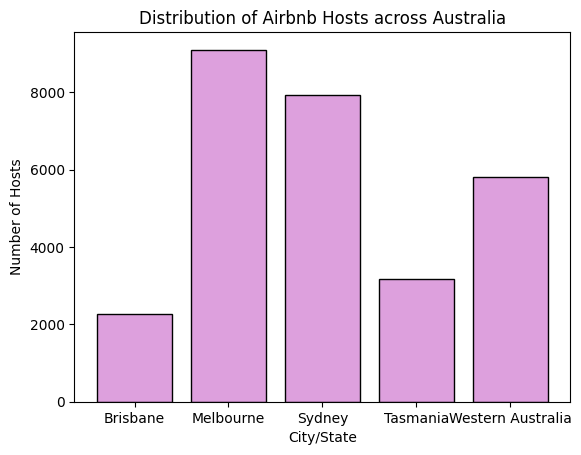

In [88]:
combined['host_since'] = pd.to_datetime(combined['host_since'])
combined['host_since_year'] = combined['host_since'].dt.year
cumulative = combined.groupby('host_since_year')['host_id'].nunique().cumsum()

plt.figure(figsize=(10, 6))
plt.plot(cumulative.index, cumulative.values, color= 'red', linewidth= 2, marker= 'o', markersize= 4)
plt.xlabel('Year')
plt.ylabel('Cumulative Number of Hosts')
plt.title('Cumulative Count of Hosts on Airbnb Australia')
plt.xticks(cumulative.index)
plt.show()



host_counts = combined.groupby('city')['host_id'].nunique()

plt.bar(host_counts.index, host_counts.values, color = 'plum', edgecolor = 'black')
plt.xlabel('City/State')
plt.ylabel('Number of Hosts')
plt.title('Distribution of Airbnb Hosts across Australia')

The cumulative count of hosts on Airbnb Australia shows explosive growth between 2013 to 2016, reflecting the period of mainstream adoption where the platform grew rapidly in both awareness and popularity. Post 2016, the curve begins to flatten, with noticeable slowdown around 2020 and 2021 likely attributable to the impact of COVID-19. While growth has resumed since, it has not returned to the pace of earlier  years - which could indicate to us that the Australian Airbnb market is approaching saturation, or more simply, that the pool of potential new hosts is shrinking as adoption rate matures. Either way, it suggests that future growth in the platform will be increasingly reliant on existing hosts and their listings rather than new hosts. 
